In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(42)

# Device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device( 'cpu')

# PINN model
class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.net = nn.Sequential()
        for i in range(len(layers) - 1):
            self.net.add_module(f"layer{i}", nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                self.net.add_module(f"tanh{i}", nn.Tanh())

    def forward(self, x):
        return self.net(x)

In [2]:
q_0=0.015
l=10
EI=20.83

# Right-hand side of Bernoulli equation
def f(x):
    return q_0*torch.sin(np.pi*x/l)

# PDE residual
def pde_loss(model, X):
    X.requires_grad_(True)
    u = model(X)
    u_x = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxx = torch.autograd.grad(u_xx, X, torch.ones_like(u_x), create_graph=True)[0]
    u_xxxx = torch.autograd.grad(u_xxx, X, torch.ones_like(u_x), create_graph=True)[0]
    source = f(X)
    return torch.mean((source-u_xxxx*EI)**2)

# Boundary loss
def boundary_loss(model, Xb):
    Xb.requires_grad_(True)
    u=model(Xb)
    u_x = torch.autograd.grad(u, Xb, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, Xb, torch.ones_like(u_x), create_graph=True)[0]
    loss_D = torch.mean(u**2)
    loss_N = torch.mean(u_xx**2)
    return loss_D, loss_N

# Generate collocation and boundary points
def generate_points(n_interior):
    x_in = torch.linspace(0,10,n_interior).reshape(n_interior,1).to(device)
    x_b = torch.tensor([[0],[10]], dtype=torch.float32).to(device)
    return x_in, x_b

# Train the model

###########(__init__)############
layers = [1, 120, 120,  1]
model = PINN(layers).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
X_in, X_b = generate_points(1000)
loss_vec = []

###########(__run__)#############
# optimizer.param_groups[0]['lr'] = 1e-5


In [3]:
for epoch in range(40000):

    optimizer.zero_grad()
    loss_in = pde_loss(model, X_in)
    loss_bd, loss_bn = boundary_loss(model, X_b)
    loss = (1000)* loss_in + (10)* loss_bd + (100)* loss_bn
    loss.backward()
    optimizer.step()
    loss_vec.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:05d}, Loss_in: {loss_in.item():.2e} | Loss_bd: {loss_bd.item():.2e} | Loss_bn: {loss_bn.item():.2e} | Total Loss: {loss.item():.2e}") 

Epoch 00000, Loss_in: 3.23e+00 | Loss_bd: 2.53e-02 | Loss_bn: 2.27e-03 | Total Loss: 3.23e+03
Epoch 00500, Loss_in: 9.53e-05 | Loss_bd: 1.07e-02 | Loss_bn: 1.72e-05 | Total Loss: 2.04e-01
Epoch 01000, Loss_in: 4.48e-05 | Loss_bd: 6.33e-04 | Loss_bn: 7.05e-05 | Total Loss: 5.82e-02
Epoch 01500, Loss_in: 3.73e-05 | Loss_bd: 1.88e-05 | Loss_bn: 7.91e-05 | Total Loss: 4.54e-02
Epoch 02000, Loss_in: 3.06e-05 | Loss_bd: 6.74e-06 | Loss_bn: 7.76e-05 | Total Loss: 3.84e-02
Epoch 02500, Loss_in: 2.47e-05 | Loss_bd: 1.21e-05 | Loss_bn: 7.73e-05 | Total Loss: 3.26e-02
Epoch 03000, Loss_in: 1.95e-05 | Loss_bd: 1.52e-05 | Loss_bn: 7.96e-05 | Total Loss: 2.77e-02
Epoch 03500, Loss_in: 1.50e-05 | Loss_bd: 1.57e-05 | Loss_bn: 8.43e-05 | Total Loss: 2.36e-02
Epoch 04000, Loss_in: 1.13e-05 | Loss_bd: 1.52e-05 | Loss_bn: 9.04e-05 | Total Loss: 2.05e-02
Epoch 04500, Loss_in: 8.52e-06 | Loss_bd: 1.49e-05 | Loss_bn: 9.63e-05 | Total Loss: 1.83e-02
Epoch 05000, Loss_in: 6.87e-06 | Loss_bd: 1.55e-05 | Loss_bn

KeyboardInterrupt: 

C:\Users\iagr9\AppData\Local\Temp\ipykernel_136132\2142286619.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)


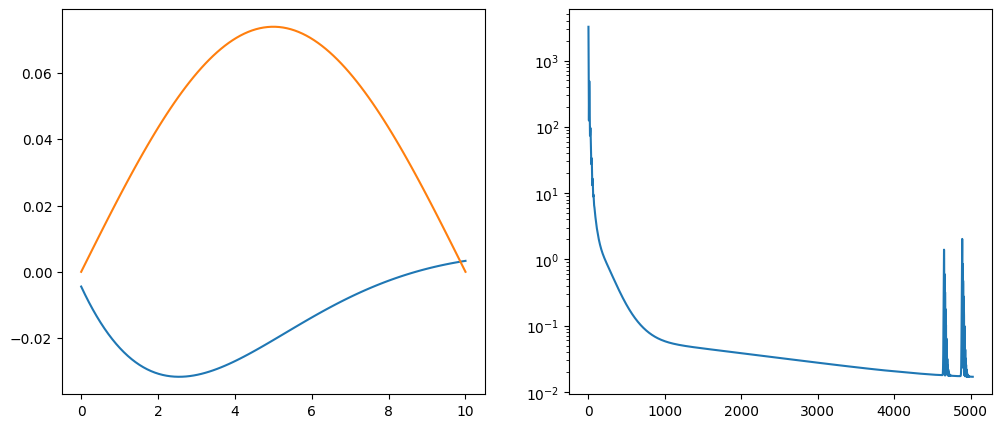

In [4]:
x = torch.linspace(0,10,100).reshape(100,1)
u_exact = q_0*l**4/(np.pi**4*EI)*np.sin(np.pi*x/l)
model.cpu()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(x,model(x).detach().numpy())
ax[0].plot(x,u_exact)

ax[1].plot(loss_vec)
ax[1].set_yscale('log')

C:\Users\iagr9\AppData\Local\Temp\ipykernel_100516\3098600691.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model.pth'))


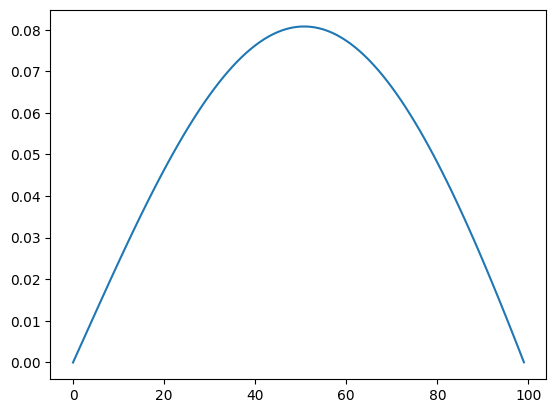

In [ ]:
# torch.save(model.state_dict(), 'model.pth')
# model = PINN([1, 120, 120,  1])  

# # Step 2: Load the saved state_dict
# model.load_state_dict(torch.load('model.pth'))

# # Step 3: Set the model to evaluation mode (optional)
# model.eval()

# plt.plot(model(x).detach().numpy())
